In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

In [3]:
df = pd.read_csv("dataset/credit_risk_cleaned.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
X = df.drop('Class', axis=1)

y = df['Class']

In [5]:
scaler = StandardScaler()

X['Amount'] = scaler.fit_transform(X[['Amount']])

X['Time'] = scaler.fit_transform(X[['Time']])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [8]:
print("Training Data:", X_train_smote.shape)

print("Testing Data:", X_test.shape)

print("Training Target:", y_train_smote.shape)

print("Testing Target:", y_test.shape)

Training Data: (453204, 30)
Testing Data: (56746, 30)
Training Target: (453204,)
Testing Target: (56746,)


In [9]:
import pandas as pd
import numpy as np
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [10]:
print("Training Data:", X_train_smote.shape)
print("Testing Data:", X_test.shape)
print("Training Target:", y_train_smote.shape)
print("Testing Target:", y_test.shape)

Training Data: (453204, 30)
Testing Data: (56746, 30)
Training Target: (453204,)
Testing Target: (56746,)


In [11]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = "N/A"

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Logistic Regression
Accuracy: 0.9737250202657456
Precision: 0.05313700384122919
Recall: 0.8736842105263158
F1 Score: 0.10018105009052504
ROC-AUC: 0.9618504434817429

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



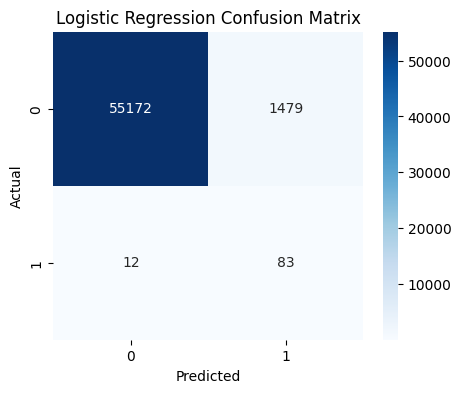

In [12]:
log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_smote, y_train_smote)

evaluate_model(log_model, X_test, y_test, "Logistic Regression")

Random Forest
Accuracy: 0.9994713283755683
Precision: 0.9113924050632911
Recall: 0.7578947368421053
F1 Score: 0.8275862068965517
ROC-AUC: 0.9543195688467431

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.76      0.83        95

    accuracy                           1.00     56746
   macro avg       0.96      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



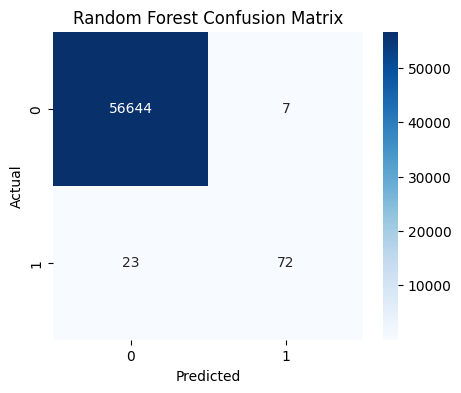

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

evaluate_model(rf_model, X_test, y_test, "Random Forest")

XGBoost
Accuracy: 0.9958234941669898
Precision: 0.2633333333333333
Recall: 0.8315789473684211
F1 Score: 0.4
ROC-AUC: 0.975199118517906

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.26      0.83      0.40        95

    accuracy                           1.00     56746
   macro avg       0.63      0.91      0.70     56746
weighted avg       1.00      1.00      1.00     56746



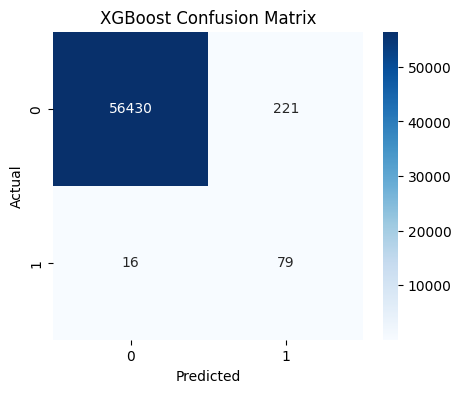

In [14]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_smote, y_train_smote)

evaluate_model(xgb_model, X_test, y_test, "XGBoost")

Isolation Forest
Accuracy: 0.9972156627779931
Precision: 0.18811881188118812
Recall: 0.2
F1 Score: 0.19387755102040816

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.19      0.20      0.19        95

    accuracy                           1.00     56746
   macro avg       0.59      0.60      0.60     56746
weighted avg       1.00      1.00      1.00     56746



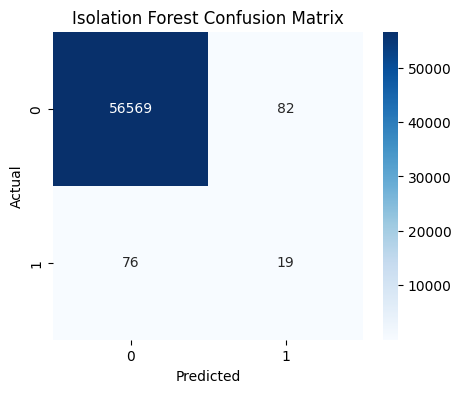

In [15]:
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.0017,
    random_state=42
)

iso_model.fit(X_train)

iso_pred = iso_model.predict(X_test)

# Isolation Forest gives:
# 1 = normal
# -1 = anomaly

iso_pred = np.where(iso_pred == -1, 1, 0)

print("=" * 60)
print("Isolation Forest")
print("=" * 60)

print("Accuracy:", accuracy_score(y_test, iso_pred))
print("Precision:", precision_score(y_test, iso_pred))
print("Recall:", recall_score(y_test, iso_pred))
print("F1 Score:", f1_score(y_test, iso_pred))

print("\nClassification Report:")
print(classification_report(y_test, iso_pred))

cm = confusion_matrix(y_test, iso_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Isolation Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
results = []

models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# Isolation Forest separately
results.append({
    "Model": "Isolation Forest",
    "Accuracy": accuracy_score(y_test, iso_pred),
    "Precision": precision_score(y_test, iso_pred),
    "Recall": recall_score(y_test, iso_pred),
    "F1 Score": f1_score(y_test, iso_pred),
    "ROC-AUC": "N/A"
})

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.973725,0.053137,0.873684,0.100181,0.96185
1,Random Forest,0.999471,0.911392,0.757895,0.827586,0.95432
2,XGBoost,0.995823,0.263333,0.831579,0.400000,0.975199
3,Isolation Forest,0.997216,0.188119,0.200000,0.193878,N/A


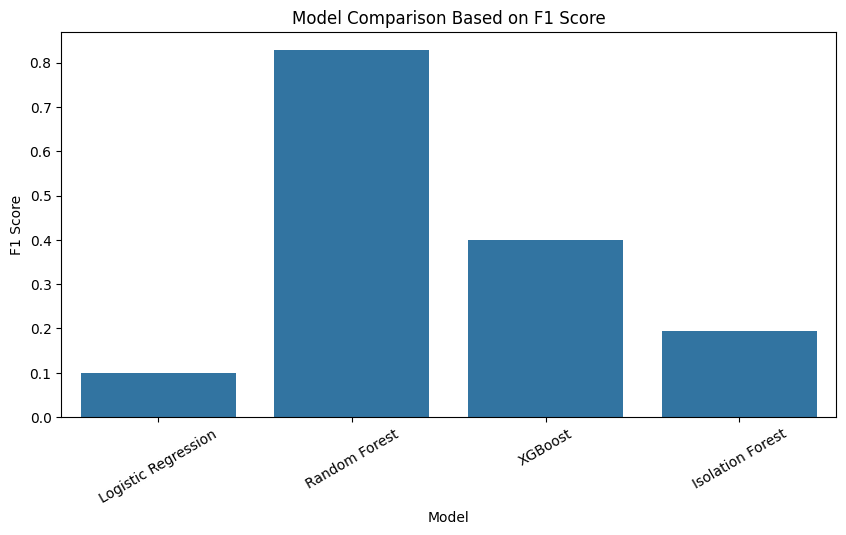

In [17]:
plt.figure(figsize=(10,5))

sns.barplot(x="Model", y="F1 Score", data=results_df)

plt.title("Model Comparison Based on F1 Score")
plt.xticks(rotation=30)
plt.show()

In [18]:
import joblib

joblib.dump(rf_model, "models/fraud_detection_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [19]:
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

In [20]:
results_df.to_csv(
    "reports/model_comparison_results.csv",
    index=False
)

In [21]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,V14,0.195029
10,V10,0.115016
12,V12,0.098714
4,V4,0.094295
17,V17,0.091678
16,V16,0.056576
11,V11,0.056238
3,V3,0.055112
2,V2,0.038038
9,V9,0.025604


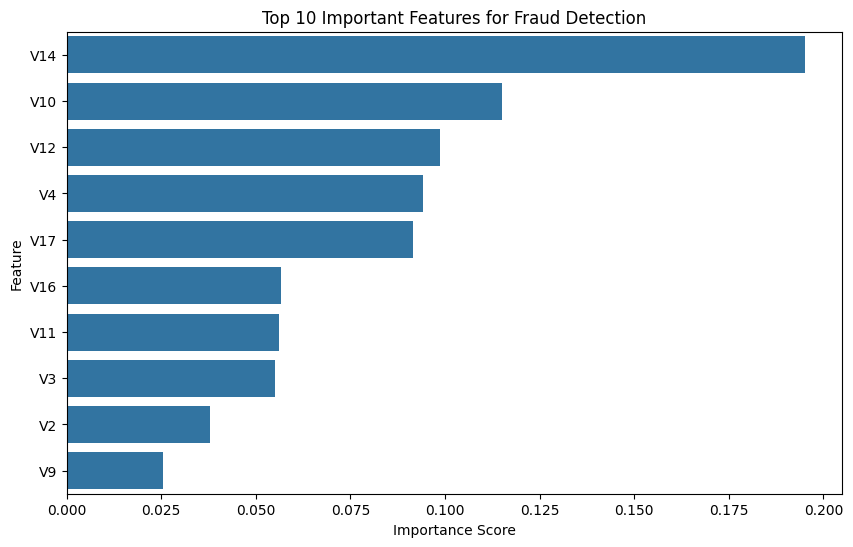

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features for Fraud Detection")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [23]:
feature_importance.to_csv("reports/feature_importance.csv", index=False)

print("Feature importance saved successfully")

Feature importance saved successfully


In [24]:
def fraud_risk_category(probability):
    if probability < 0.30:
        return "Low Risk"
    elif probability < 0.70:
        return "Medium Risk"
    else:
        return "High Risk"

In [25]:
sample_data = X_test.head(10)

fraud_probabilities = rf_model.predict_proba(sample_data)[:, 1]

risk_results = pd.DataFrame({
    "Fraud Probability": fraud_probabilities,
    "Risk Category": [fraud_risk_category(p) for p in fraud_probabilities]
})

risk_results

,Fraud Probability,Risk Category
0,0.0,Low Risk
1,0.0,Low Risk
2,0.0,Low Risk
3,0.0,Low Risk
4,0.0,Low Risk
5,0.0,Low Risk
6,0.0,Low Risk
7,0.0,Low Risk
8,0.0,Low Risk
9,0.0,Low Risk


In [26]:
risk_results.to_csv("reports/sample_risk_predictions.csv", index=False)

print("Sample risk predictions saved successfully")

Sample risk predictions saved successfully


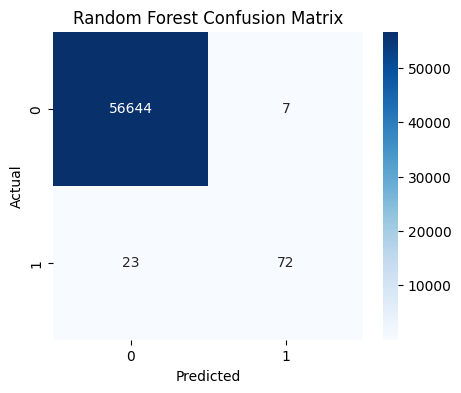

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_model.predict(X_test))

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("reports/confusion_matrix.png")

plt.show()

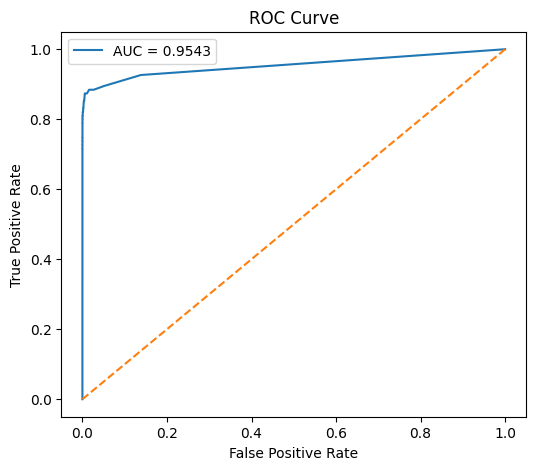

In [29]:
from sklearn.metrics import roc_curve, auc

y_prob = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig("reports/roc_curve.png")

plt.show()

In [30]:
fraud_indices = df[df["Class"] == 1].index.tolist()

print(fraud_indices[:20])

[534, 616, 4886, 6072, 6293, 6295, 6298, 6300, 6302, 6388, 6407, 6433, 6490, 6570, 6602, 6678, 6680, 6695, 6735, 6781]


In [31]:
normal_indices = df[df["Class"] == 0].index.tolist()

print(normal_indices[:20])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
